In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

import scanpy as sc
import numpy as np
import anndata as ad

from tqdm.notebook import tqdm

In [ ]:
adata = sc.read_h5ad("../../project_folder/data/combosciplex/combosciplex.h5ad")
adata = adata[:, adata.var.highly_variable]

In [3]:
adata

View of AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, dim_in, hidden_dim, dim_out):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(dim_in, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim_out)
        )

        self.decoder = nn.Sequential(
            nn.Linear(dim_out, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim_in)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [5]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = CustomDataset(adata.X.toarray())
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

In [72]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1100
Epoch [2/20], Loss: 0.1064
Epoch [3/20], Loss: 0.1046
Epoch [4/20], Loss: 0.1035
Epoch [5/20], Loss: 0.1036
Epoch [6/20], Loss: 0.1026
Epoch [7/20], Loss: 0.1026
Epoch [8/20], Loss: 0.1033
Epoch [9/20], Loss: 0.1026
Epoch [10/20], Loss: 0.1022
Epoch [11/20], Loss: 0.1020
Epoch [12/20], Loss: 0.1012
Epoch [13/20], Loss: 0.1033
Epoch [14/20], Loss: 0.1021
Epoch [15/20], Loss: 0.1024
Epoch [16/20], Loss: 0.1013
Epoch [17/20], Loss: 0.1018
Epoch [18/20], Loss: 0.1014
Epoch [19/20], Loss: 0.1034
Epoch [20/20], Loss: 0.1027


In [73]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model(torch.tensor(orig).float().to(device)).cpu().numpy()

In [74]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


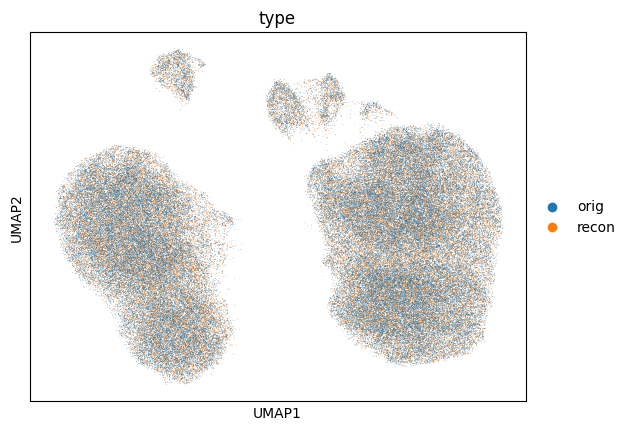

In [75]:
sc.pl.umap(combined, color="type")

In [7]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    adata.obsm["latent_10"] = model.encoder(torch.tensor(orig).float().to(device)).cpu().numpy()

/tmp/ipykernel_4142024/1188948143.py:5: ImplicitModificationWarning: Setting element `.obsm['latent_10']` of view, initializing view as actual.
  adata.obsm["latent_10"] = model.encoder(torch.tensor(orig).float().to(device)).cpu().numpy()


In [ ]:
torch.save(model.state_dict(), "../../project_folder/results/combosciplex/weights/ae_models/ae_10_dim.ckpt")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=10
).to(device)
model.load_state_dict(state_dict=torch.load("../../project_folder/results/combosciplex/weights/ae_models/ae_10_dim.ckpt", weights_only=True))

<All keys matched successfully>

In [80]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=5
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1114
Epoch [2/20], Loss: 0.1079
Epoch [3/20], Loss: 0.1071
Epoch [4/20], Loss: 0.1067
Epoch [5/20], Loss: 0.1064
Epoch [6/20], Loss: 0.1064
Epoch [7/20], Loss: 0.1049
Epoch [8/20], Loss: 0.1070
Epoch [9/20], Loss: 0.1062
Epoch [10/20], Loss: 0.1053
Epoch [11/20], Loss: 0.1055
Epoch [12/20], Loss: 0.1044
Epoch [13/20], Loss: 0.1057
Epoch [14/20], Loss: 0.1045
Epoch [15/20], Loss: 0.1045
Epoch [16/20], Loss: 0.1044
Epoch [17/20], Loss: 0.1052
Epoch [18/20], Loss: 0.1046
Epoch [19/20], Loss: 0.1051
Epoch [20/20], Loss: 0.1054


In [81]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model(torch.tensor(orig).float().to(device)).cpu().numpy()

In [82]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


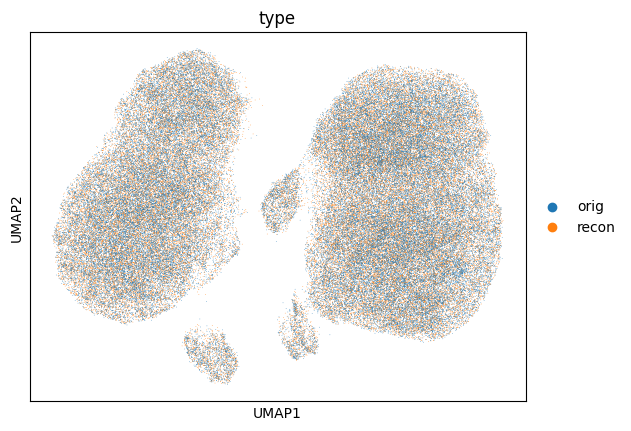

In [83]:
sc.pl.umap(combined, color="type")

In [9]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    adata.obsm["latent_5"] = model.encoder(torch.tensor(orig).float().to(device)).cpu().numpy()

In [ ]:
torch.save(model.state_dict(), "../../project_folder/results/combosciplex/weights/ae_models/ae_5_dim.ckpt")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=5
).to(device)
model.load_state_dict(state_dict=torch.load("../../project_folder/results/combosciplex/weights/ae_models/ae_5_dim.ckpt", weights_only=True))

<All keys matched successfully>

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=3
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1127
Epoch [2/20], Loss: 0.1101
Epoch [3/20], Loss: 0.1106
Epoch [4/20], Loss: 0.1090
Epoch [5/20], Loss: 0.1081
Epoch [6/20], Loss: 0.1074
Epoch [7/20], Loss: 0.1075
Epoch [8/20], Loss: 0.1080
Epoch [9/20], Loss: 0.1070
Epoch [10/20], Loss: 0.1070
Epoch [11/20], Loss: 0.1064
Epoch [12/20], Loss: 0.1067
Epoch [13/20], Loss: 0.1074
Epoch [14/20], Loss: 0.1066
Epoch [15/20], Loss: 0.1066
Epoch [16/20], Loss: 0.1073
Epoch [17/20], Loss: 0.1056
Epoch [18/20], Loss: 0.1066
Epoch [19/20], Loss: 0.1052
Epoch [20/20], Loss: 0.1076


In [55]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model(torch.tensor(orig).float().to(device)).cpu().numpy()

In [56]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


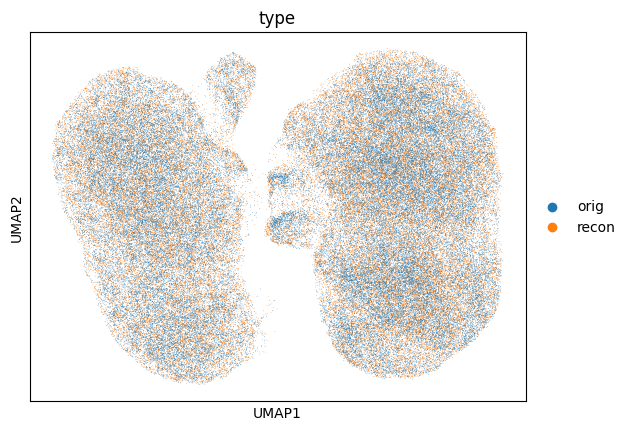

In [57]:
sc.pl.umap(combined, color="type")

In [58]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    adata.obsm["latent_3"] = model.encoder(torch.tensor(orig).float().to(device)).cpu().numpy()

In [ ]:
torch.save(model.state_dict(), "../../project_folder/results/combosciplex/weights/ae_models/ae_3_dim.ckpt")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=3
).to(device)
model.load_state_dict(state_dict=torch.load("../../project_folder/results/combosciplex/weights/ae_models/ae_3_dim.ckpt", weights_only=True))

<All keys matched successfully>

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder(
    dim_in=5000,
    hidden_dim=1024,
    dim_out=2
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1207
Epoch [2/20], Loss: 0.1125
Epoch [3/20], Loss: 0.1124
Epoch [4/20], Loss: 0.1119
Epoch [5/20], Loss: 0.1104
Epoch [6/20], Loss: 0.1101
Epoch [7/20], Loss: 0.1108
Epoch [8/20], Loss: 0.1102
Epoch [9/20], Loss: 0.1092
Epoch [10/20], Loss: 0.1092
Epoch [11/20], Loss: 0.1097
Epoch [12/20], Loss: 0.1091
Epoch [13/20], Loss: 0.1102
Epoch [14/20], Loss: 0.1087
Epoch [15/20], Loss: 0.1090
Epoch [16/20], Loss: 0.1088
Epoch [17/20], Loss: 0.1091
Epoch [18/20], Loss: 0.1088
Epoch [19/20], Loss: 0.1086
Epoch [20/20], Loss: 0.1071


In [43]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model(torch.tensor(orig).float().to(device)).cpu().numpy()

In [44]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


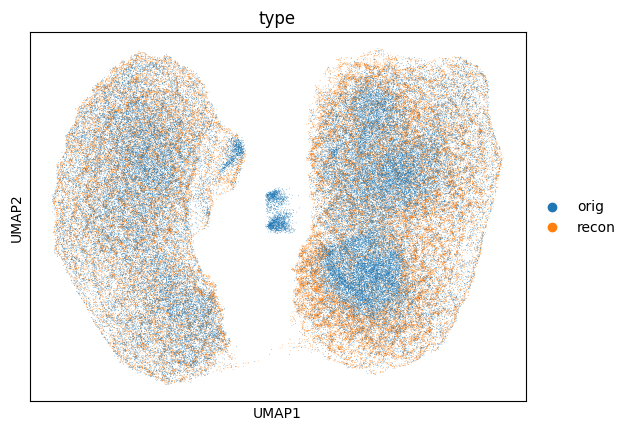

In [45]:
sc.pl.umap(combined, color="type")

In [61]:
adata

AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'latent_10', 'latent_5', 'latent_3'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.write_h5ad("../../project_folder/data/combosciplex/combosciplex_with_ae_latent.h5ad")